# **House Prices Regression Project**

> Ajouter une citation



## **Introduction**

In this project, we study a supervised **regression** problem using the
**House Prices** dataset.  
The objective is to predict the **sale price of a house** based on its
physical characteristics, location, and other attributes.

This project follows the standard regression workflow presented in the
course, including:
- Data loading
- Data exploration
- Data preprocessing
- Feature engineering
- Model training and tuning
- Model evaluation

# **Get data**

### Importing Libraries

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
import urllib.request
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin



### Loading the Dataset

In [ ]:
def load_housing_data():
    # where the downloaded file will be stored locally
    csv_path = Path("data/housing/housing.csv")

    if not csv_path.is_file():
        Path("data/housing").mkdir(parents=True, exist_ok=True) ## creation of the datasets directory and its parent directories if necessary.
        url = "https://raw.githubusercontent.com/JoannaBroniarek/House-Prices-Advanced-Regression-Techniques/master/dane/train.csv"
        ## Downloads the file from the URL and saves it to disk using the name defined in tarball_path (the CSV file is downloaded directly).
        print(f"Télécharge le fichier depuis {url}")
        urllib.request.urlretrieve(url, csv_path)

    ## we read it directly!
    return pd.read_csv(csv_path)

In [ ]:
data = load_housing_data()

Télécharge le fichier depuis https://raw.githubusercontent.com/JoannaBroniarek/House-Prices-Advanced-Regression-Techniques/master/dane/train.csv


We define a function to load the housing dataset. This function:

* Ensures that the dataset exists locally.

* Downloads the data if it is not already available.

* Reads the CSV file into a pandas DataFrame.


### Initial Inspection of the Data

#### number of rows and columns

In [ ]:
data.shape

(1460, 81)

(1460, 81) indicates that our dataset contains 1,460 observations and 81 variables.

* Each of the 1,460 rows represents a unique house in the dataset.

* The 81 columns correspond to different features describing each house, including structural characteristics, location-related attributes, and the target variable (SalePrice).

---

#### the first few rows

In [ ]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


we display the first five rows of the dataset in order to visually inspect the data.

From the displayed rows, we observe that:

* Each row represents a single house, uniquely identified by the Id column.

* The dataset contains a mix of **numerical variables** (e.g., LotArea, LotFrontage, SalePrice) and **categorical variables** (e.g., MSZoning, Street, LotShape, SaleCondition).

* The target variable, SalePrice, is clearly present and represents the house sale price in monetary units.

* Several columns contain missing values, visible as NaN (e.g., Alley, PoolQC, Fence, MiscFeature). This confirms the need for missing-value handling during data preprocessing.


----

#### inspect data types and detect missing values

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

we obtain a concise summary of the dataset, including the number of observations, feature names, data types, and the count of non-null values.

From the output, we observe that:

* The dataset contains 1,460 entries and 81 columns, which is consistent with the result obtained from data.shape.

* The features are composed of:

    * 35 integer variables, mostly representing counts or discrete measurements (e.g., number of rooms, area sizes).

    * 3 floating-point variables, typically associated with continuous measurements that may include missing values.

    * 43 categorical variables, represented as objects, describing qualitative characteristics of the houses.

Columns with significant missing values include:

* PoolQC: 1,453 missing values
    → Most houses do not have a pool.

* MiscFeature: 1,406 missing values
    → Special miscellaneous features are rare.

* Alley: 1,369 missing values
    → The majority of houses do not have alley access.

* Fence: 1,179 missing values
    → Most properties are not fenced.

* FireplaceQu: 690 missing values
    → Many houses do not have fireplaces.

* LotFrontage: 259 missing values
    → Frontage information is missing for a subset of properties.

* Basement-related features (BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinType2): approximately 37–38 missing values
    → These correspond to houses without basements.

* Garage-related features (GarageType, GarageYrBlt, GarageFinish, GarageQual, GarageCond): 81 missing values
    → These values are missing for houses without garages.

---

#### obtain summary statistics for numerical features

In [ ]:
data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


we obtain a statistical summary of all numerical variables in the dataset.

---


In [ ]:
data.describe(include="object")

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,...,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,...,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,...,870,605,1311,1326,1340,3,157,49,1267,1198


#### Checking for Duplicated Observations

In [ ]:
data.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
1455,False
1456,False
1457,False
1458,False


In [ ]:
data.duplicated().sum()

np.int64(0)

the result shows False for all rows (and the sum of duplicates is zero), this means that no duplicated observations are present in the dataset.
This confirms that each row represents a unique house and that the dataset is clean with respect to duplication.

#### Inspecting the Dataset Columns

In [ ]:
data.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

## **Create a Test Set**

In [ ]:
corr_matrix=data.select_dtypes(include='number').corr()
target_corr = corr_matrix['SalePrice'].sort_values(ascending=False)
strongest_corr_feature = target_corr.drop('SalePrice').abs().idxmax()
strongest_corr_value = target_corr[strongest_corr_feature]
print(f"Feature with strongest correlation: {strongest_corr_feature} ({strongest_corr_value})")


Feature with strongest correlation: OverallQual (0.7909816005838053)


In [ ]:
data["OverallQual"].value_counts()

,count
OverallQual,
5,397
6,374
7,319
8,168
4,116
9,43
3,20
10,18
2,3


The `OverallQual` feature is **highly imbalanced**, with most houses rated 5–7, few high-quality houses (8–10), and very few low-quality houses (1–3).

#### Train–Test Split with Stratification

In [ ]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(data, test_size=0.2, stratify=data["OverallQual"],random_state=42)


In [ ]:
print("Taille de X_train :", train_set.shape)
print("Taille de y_train :", test_set.shape)

Taille de X_train : (1168, 81)
Taille de y_train : (292, 81)


We split the dataset into **training and test sets** using `train_test_split` from `scikit-learn`, specifying a `test_size` of 0.2 and stratifying by the `OverallQual` feature.

In preparing our dataset for modeling, we needed to split it into training and test sets in a way that preserves the underlying distribution of important features. Several methods are commonly suggested in the literature:

1- **Random splitting using train_test_split without stratification** :  This is the simplest approach but risks **imbalanced representation** of rare but important categories in the test set. For example, houses with OverallQual of 1, 2, 9, or 10 are few, and a random split might exclude them from either the training or test set, leading to biased evaluation.

2- **Splitting based on ID hashing (using crc32)** : This method ensures **deterministic splitting**: a given row always ends up in the same subset. While robust for reproducibility, it does not automatically account for feature distributions, and rare but predictive categories might still be unevenly represented.

3- **Stratified Splitting Based on a Key Feature (OverallQual)**: -> Chosen Method

This method divides the data while preserving the proportion of `OverallQual` ratings in both training and test sets.

Pros:

Maintains representation of rare but important categories.

Preserves the strong correlation between `OverallQual` and `SalePrice`, ensuring the test set is representative.

Reduces bias in model evaluation and prevents the model from being tested on unseen feature values.

* **Why this is better for our dataset**:

`OverallQual` is **ordinal** and strongly influences the target (`SalePrice`).

Its distribution is imbalanced, so stratification avoids having extreme ratings absent from either set.

Ensures robust, academically rigorous evaluation metrics.

* **Source:** [Why do we use stratify in train_test_split](https://medium.com/%40aymuosmukherjee/why-do-we-use-stratify-in-train-test-split-e3eb296a5494)

---

# **Explore and Visualize the Data to Gain Insights**

We generate various plots (such as histograms and scatter plots) to analyze feature distributions and relationships with the target variable (SalePrice).
Visualization allows us to:

* Detect skewed distributions.

* Identify correlations between variables.

* Reveal potential outliers.

In [ ]:
housing = train_set.copy()

#### Missing values

In [ ]:
missing=housing.isnull().sum().sort_values(ascending=False)
print("Top missing columns:\n", missing.head(10))

Top missing columns:
 PoolQC          1163
MiscFeature     1127
Alley           1098
Fence            933
MasVnrType       705
FireplaceQu      541
LotFrontage      206
GarageQual        63
GarageFinish      63
GarageType        63
dtype: int64


Text(0.5, 1.0, 'Features with the highest percentage of Nan values')

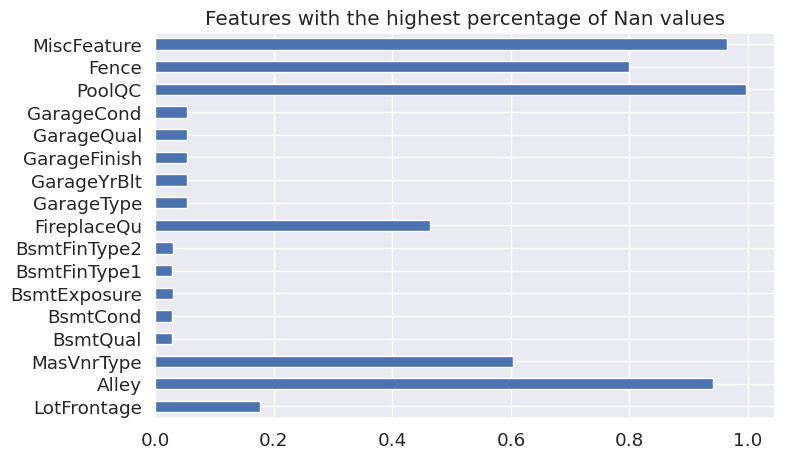

In [ ]:
col_nan = housing.isna().sum() / housing.shape[0]
plt.figure(figsize=(8, 5))
sns.set(font_scale=1.2)
col_nan[col_nan > 0.01].plot(kind = "barh")
plt.title("Features with the highest percentage of Nan values")

Several features have missing values. `PoolQC`, `MiscFeature`, `Alley`, and `Fence` are missing most entries, indicating that these attributes are rare or not applicable for many houses. Moderate missing values occur in `MasVnrType`, `FireplaceQu`, `LotFrontage`, and **garage-related** columns.

#### Feature Relationships

##### Correlation Analysis with SalePrice

In [ ]:
corr_matrix = housing.select_dtypes(include='number').corr()

In [ ]:
corr_matrix['SalePrice'].sort_values(ascending=False)

,SalePrice
SalePrice,1.000000
OverallQual,0.800531
GrLivArea,0.700908
GarageCars,0.651388
GarageArea,0.634647
TotalBsmtSF,0.604969
1stFlrSF,0.596394
FullBath,0.563145
TotRmsAbvGrd,0.534714
YearBuilt,0.528381


##### Correlation Heatmap

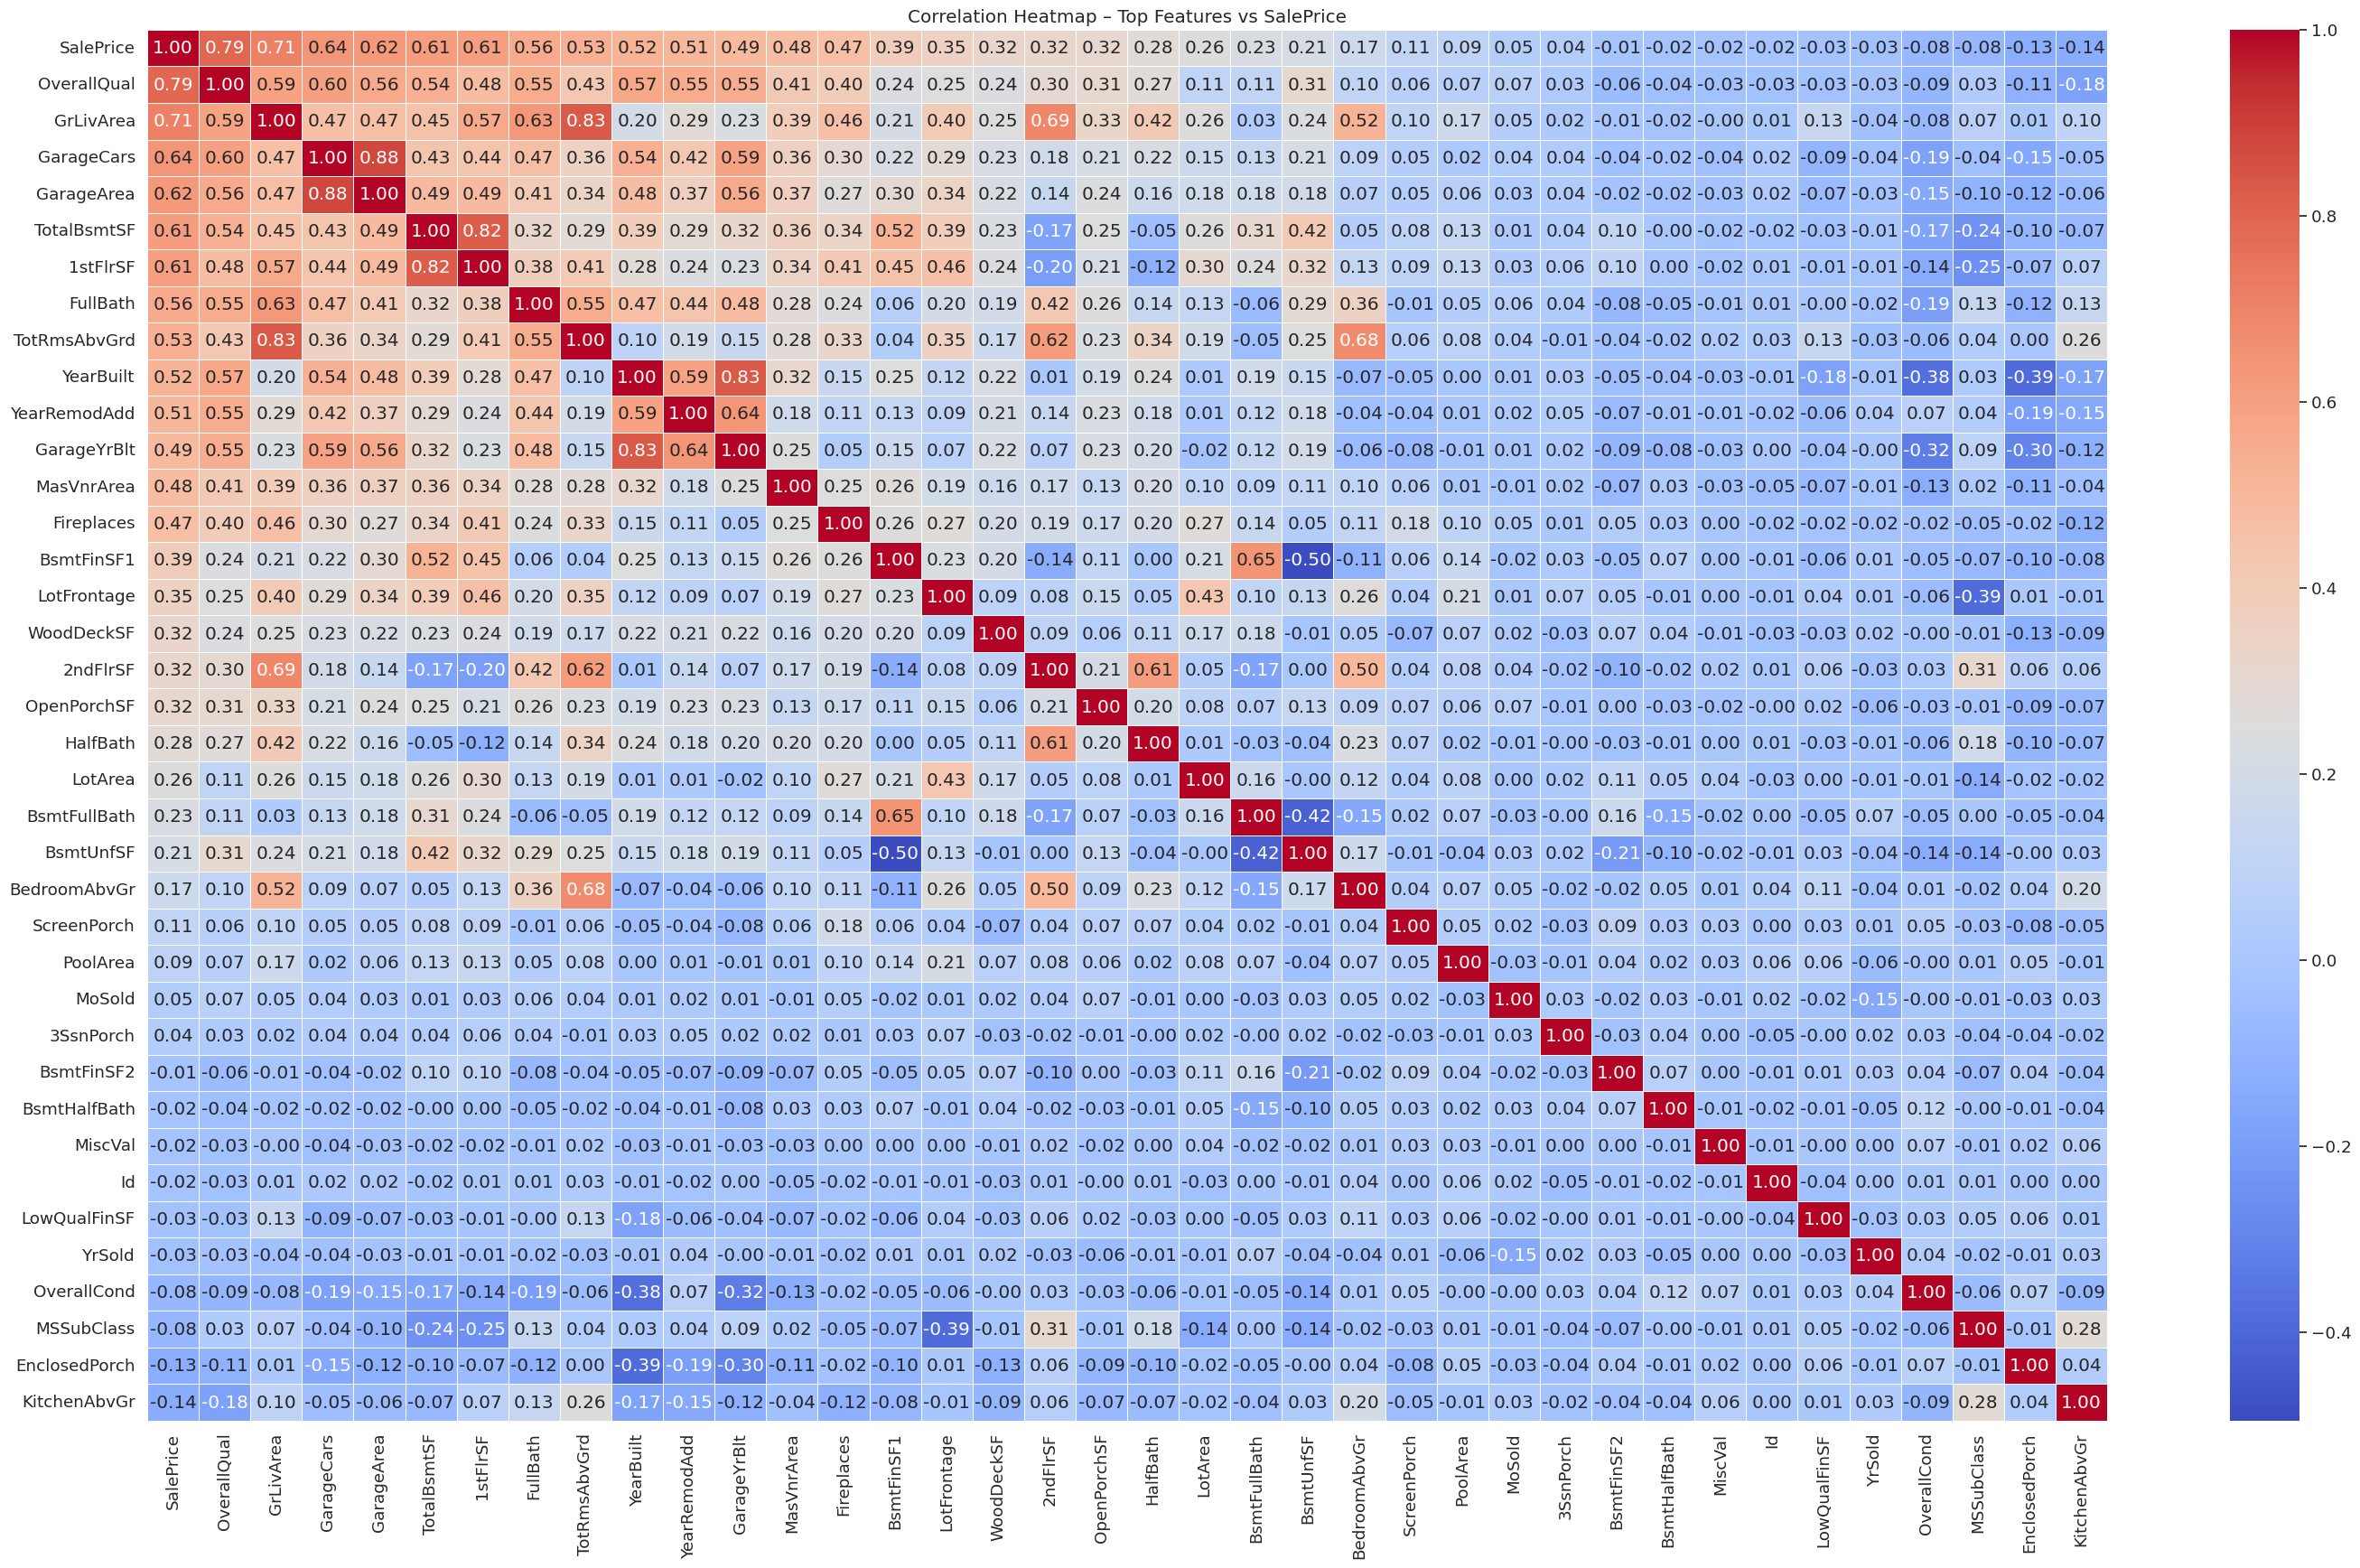

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selection of numerical features.
corr_matrix = data.select_dtypes(include='number').corr()

# Focus on the variables most correlated with SalePrice.
top_corr = corr_matrix["SalePrice"].sort_values(ascending=False)
top_features = top_corr.index

plt.figure(figsize=(35, 20))
sns.heatmap(
    corr_matrix.loc[top_features, top_features],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Heatmap – Top Features vs SalePrice")
plt.show()

We computed the Pearson correlation coefficients between numerical features and the target variable SalePrice to identify which variables are most strongly associated with house prices. The output shows a clear ranking of predictive power among the features.

* **Observations:**

   * **Top Predictors**

      * `OverallQual` has the highest correlation with `SalePrice` (0.80). This confirms that **overall material and finish quality is the most important determinant of price**.
      * `GrLivArea` (above-ground living area) is strongly correlated at 0.70, highlighting that **larger living spaces generally command higher prices**.

   * **Low or Negligible Predictors**

   * Several features have weak correlations with `SalePrice` (less than 0.3), including `LotArea` (0.28), `BedroomAbvGr` (0.17), and `OpenPorchSF` (0.32).
      * Some features are almost uncorrelated or slightly negative, such as `PoolArea` (0.015), `BsmtFinSF2` (-0.003), and `YrSold` (-0.005), suggesting they **do not provide significant predictive information for price**.

* **Implications:**

   * Features with high correlation to `SalePrice` should be **prioritized for modeling**, either as-is or after engineering additional features.

   * Some features are likely correlated with each other (e.g., `GarageCars` and `GarageArea`, `1stFlrSF` and `GrLivArea`). During modeling, we may need **regularization or feature selection** to prevent multicollinearity from inflating variance in linear models.

   * Features with very low correlation to the target could be **excluded or transformed** if they do not improve model performance, reducing noise and simplifying the model.

In [ ]:
corr_matrix =housing.select_dtypes(include='number').corr()
abs_corr_matrix =corr_matrix.abs()

#The correlation matrix is symmetric, so we only examine one half to avoid duplicates.
upper_triangle = abs_corr_matrix.where(
    np.triu(np.ones(abs_corr_matrix.shape), k=1).astype(bool)
)
high_corr_pairs = []

for col1 in upper_triangle.columns:
    for col2 in upper_triangle.index:
        if upper_triangle.loc[col1, col2] > 0.8:
            high_corr_pairs.append((col1, col2, upper_triangle.loc[col1, col2]))

print("Pairs with highly correlated features are: ")
high_corr_pairs


Pairs with highly correlated features are: 


[('OverallQual', 'SalePrice', np.float64(0.8005308265851243)),
 ('YearBuilt', 'GarageYrBlt', np.float64(0.8172686823197606)),
 ('TotalBsmtSF', '1stFlrSF', np.float64(0.8063744882639294)),
 ('GrLivArea', 'TotRmsAbvGrd', np.float64(0.8333350344078414)),
 ('GarageCars', 'GarageArea', np.float64(0.8779371743234613))]

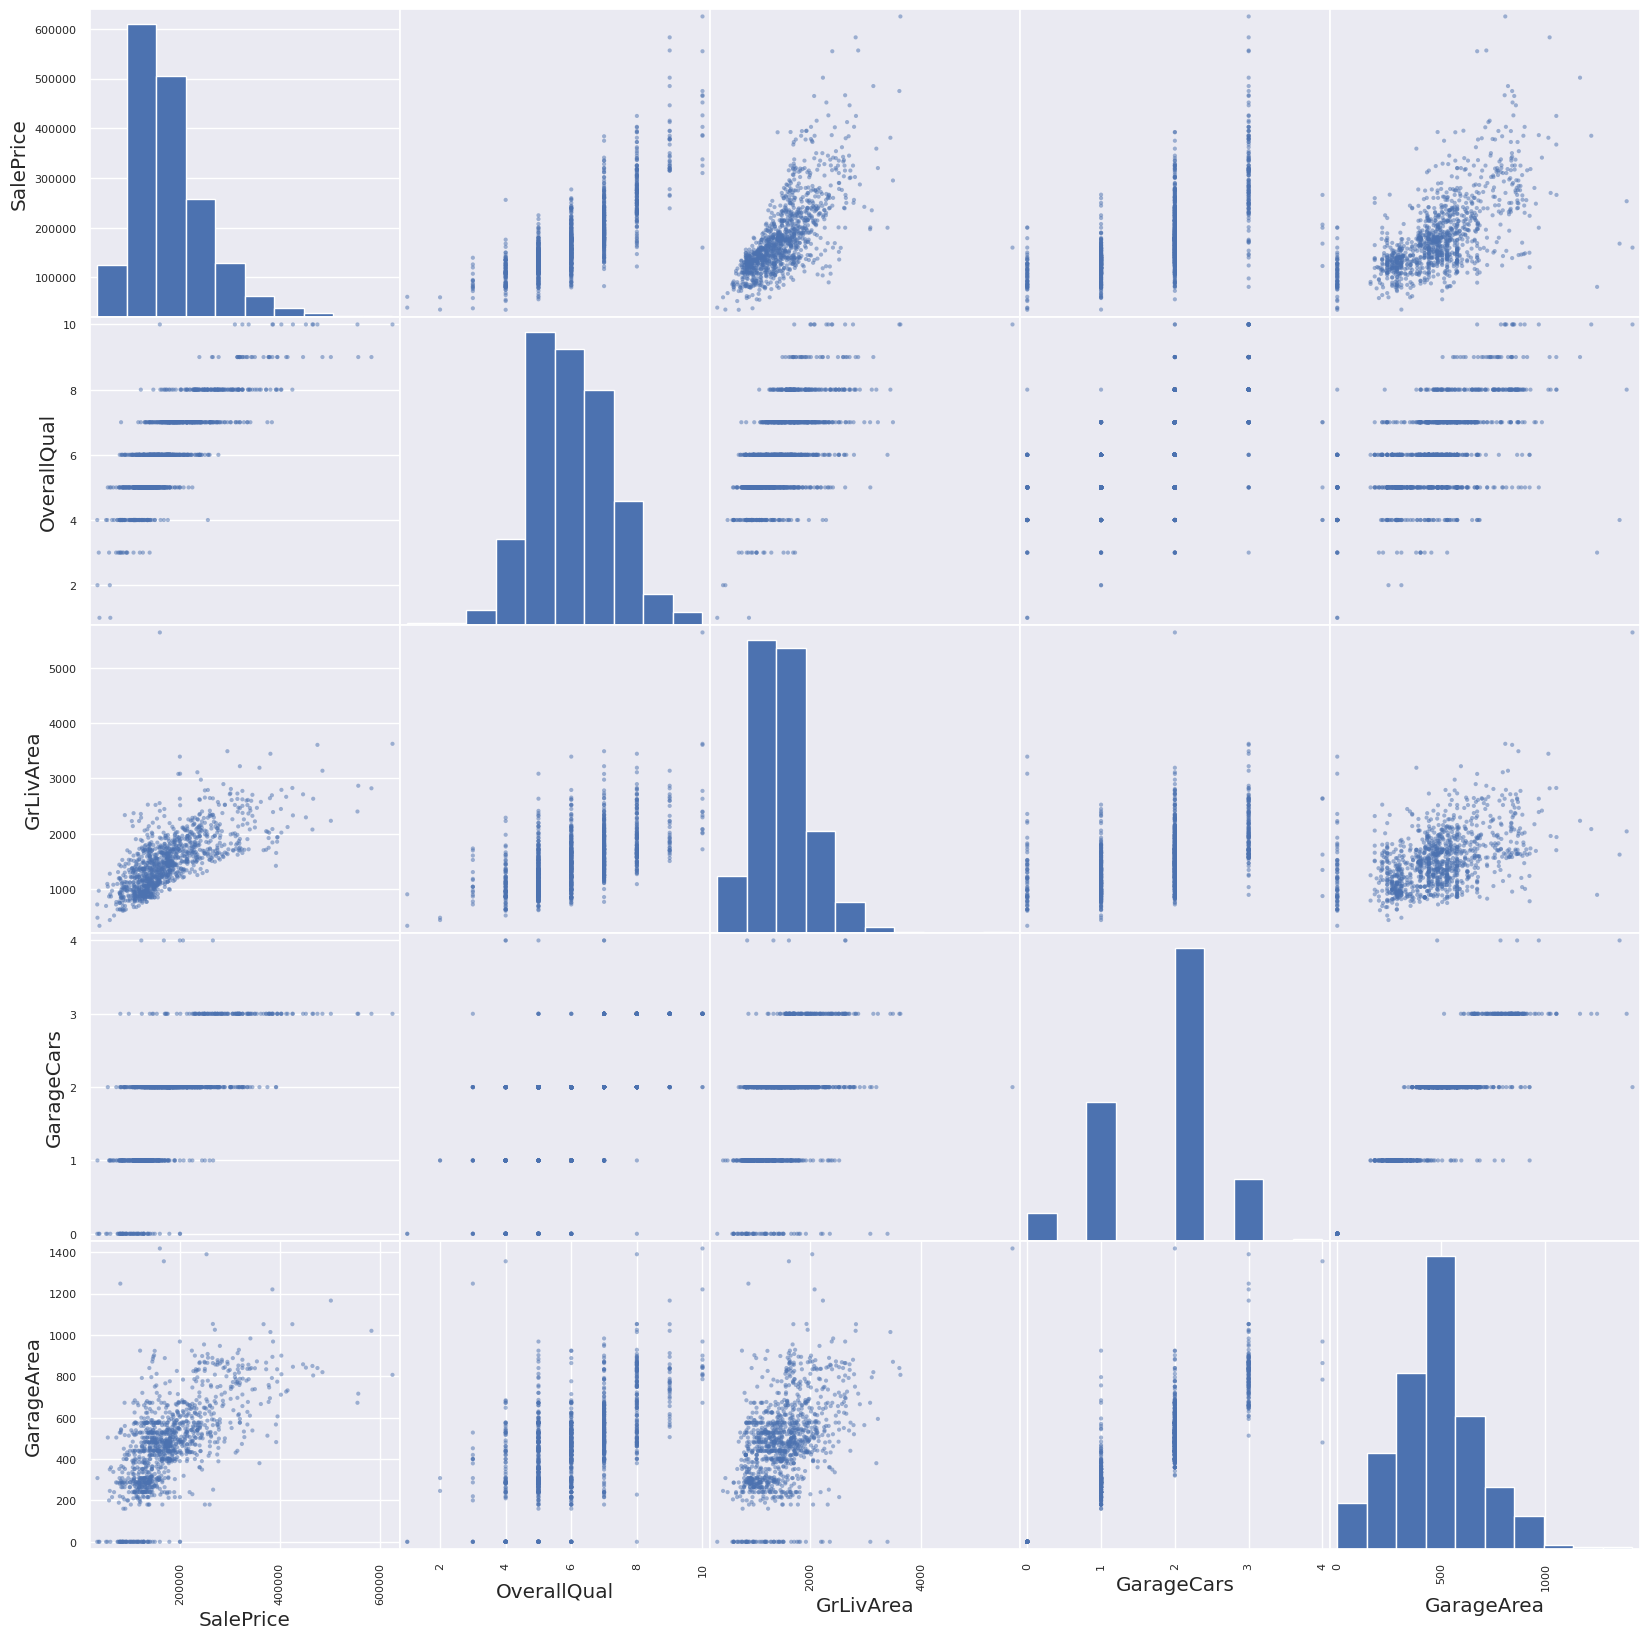

In [ ]:
attributes = top_features[:5]
scatter_matrix(train_set[attributes], figsize=(20, 20))
plt.show()

We plotted a scatter matrix for the five most correlated features with `SalePrice`: `SalePrice`, `OverallQual`, `GrLivArea`, `GarageCars`, and `GarageArea`. This visualization allows us to **see pairwise relationships, distributions, and potential outliers** at a glance.

**Key Observations & Notes:**


* **SalePrice vs OverallQual:**

  * Shows a clear **positive linear trend** – higher quality homes generally have higher prices.
  * Most values cluster around mid-range quality (5–8), with very few extreme ratings (1–3 or 10).

* **SalePrice vs GrLivArea:**

  * Strong positive correlation: larger living areas usually correspond to higher prices.
  * **Outliers:** Some houses have very large living area but moderate prices → may skew regression models.

---

#### Distribution of the Target

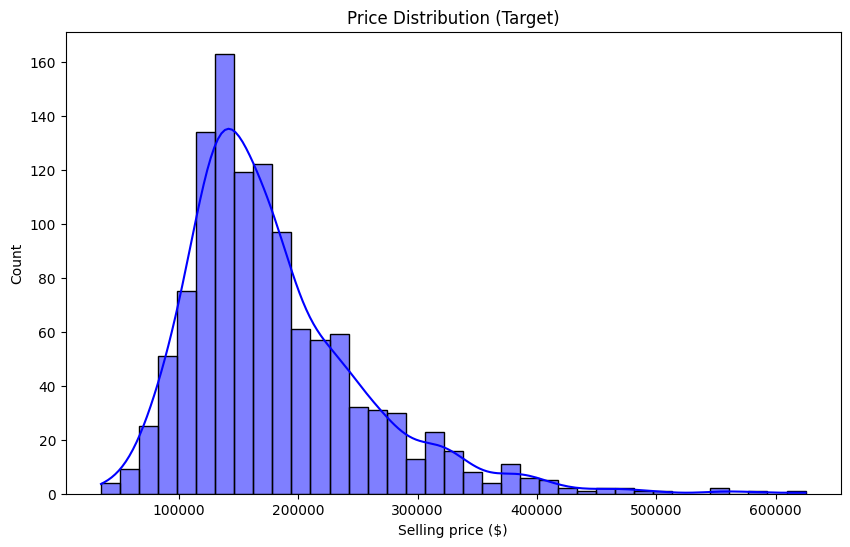

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(train_set['SalePrice'], kde=True, color="blue")
plt.title("Price Distribution (Target)")
plt.xlabel("Selling price ($)")
plt.show()


The histogram of `SalePrice` shows a **right-skewed distribution with heavy tails**. Most houses are concentrated in the lower and middle price ranges, while a small number of houses have very high prices that extend far to the right.

* This pattern indicates that extreme values (very expensive houses) are rare but have a **strong influence** on the distribution and can negatively affect models that assume normally distributed errors, such as linear regression.

Apply log transformation:

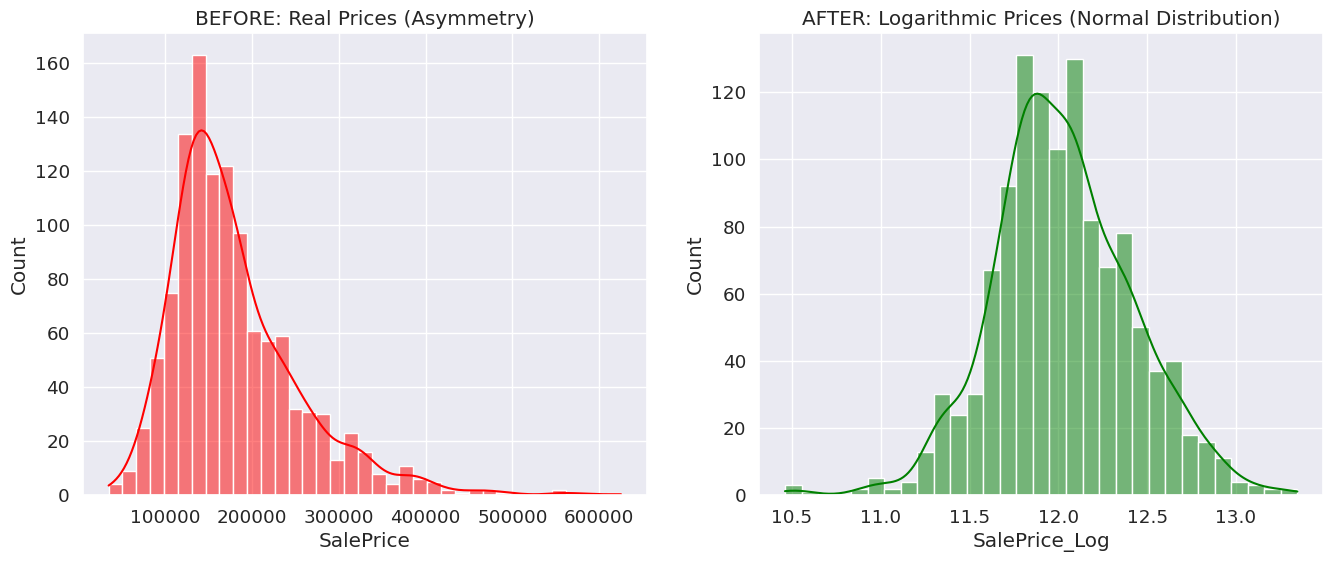

In [ ]:

train_set["SalePrice_Log"] = np.log1p(train_set["SalePrice"])

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(train_set["SalePrice"], kde=True, ax=ax[0], color="red")
ax[0].set_title("BEFORE: Real Prices (Asymmetry)")

sns.histplot(train_set["SalePrice_Log"], kde=True, ax=ax[1], color="green")
ax[1].set_title("AFTER: Logarithmic Prices (Normal Distribution)")

plt.show()

Apply square root transformation :

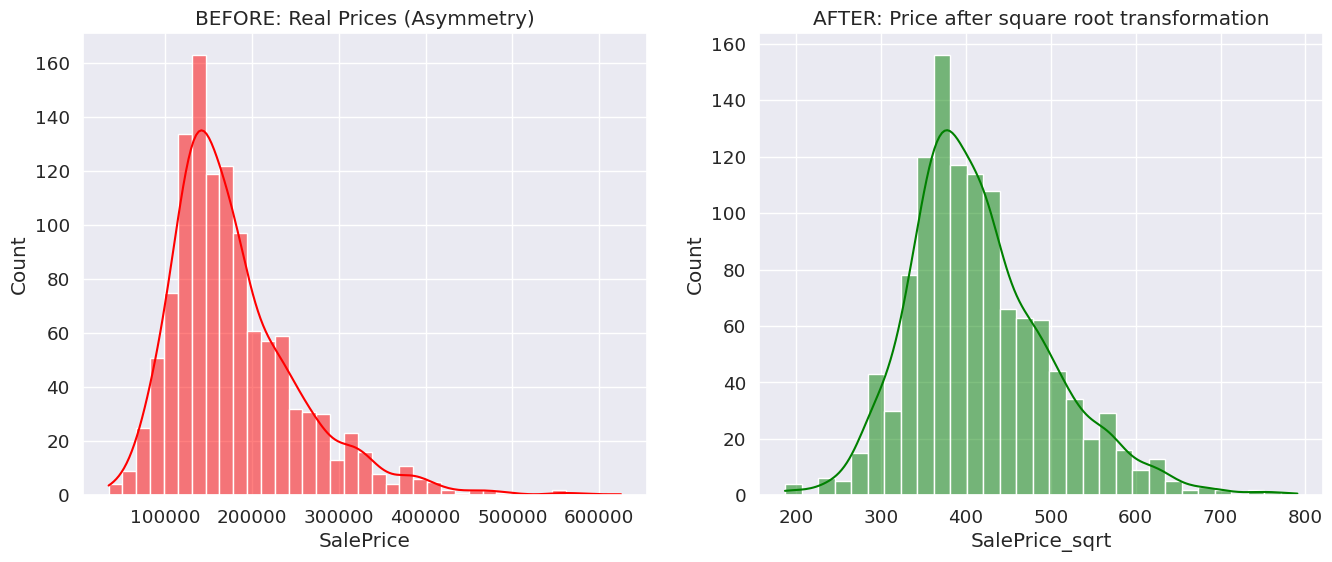

In [ ]:
train_set["SalePrice_sqrt"] = np.sqrt(train_set["SalePrice"])

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(train_set["SalePrice"], kde=True, ax=ax[0], color="red")
ax[0].set_title("BEFORE: Real Prices (Asymmetry)")

sns.histplot(train_set["SalePrice_sqrt"], kde=True, ax=ax[1], color="green")
ax[1].set_title("AFTER: Price after square root transformation")

plt.show()

Apply Yeo-Johnson (Box-Cox) transformation :

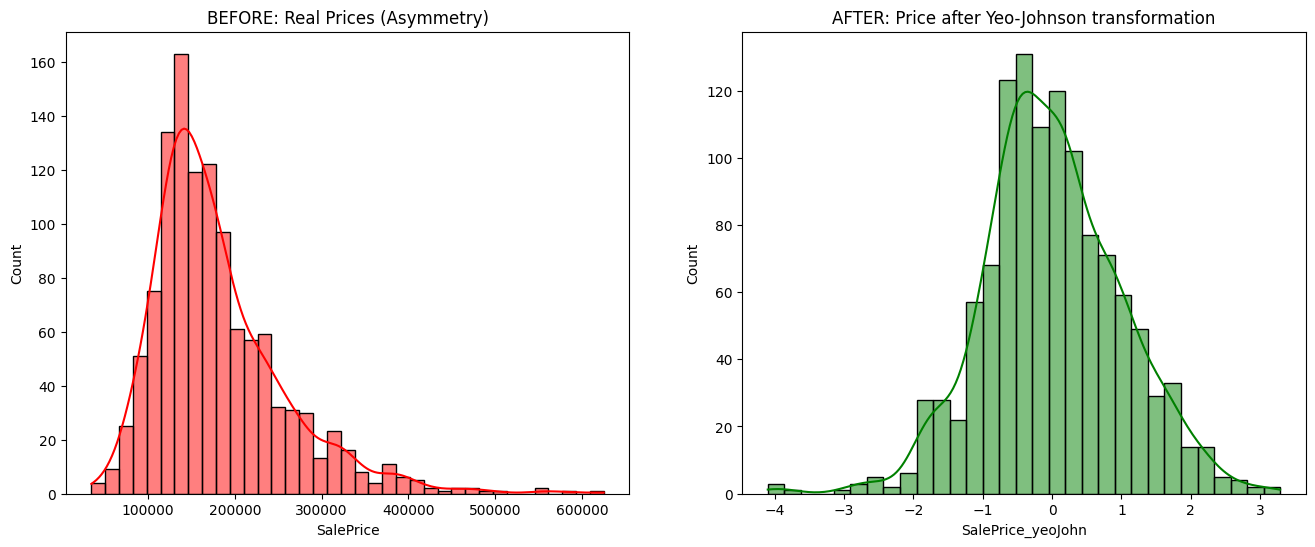

In [ ]:
from sklearn.preprocessing import PowerTransformer

# pt = PowerTransformer(method="box-cox")

pt = PowerTransformer(method="yeo-johnson")
train_set["SalePrice_yeoJohn"] = pt.fit_transform(
    train_set[["SalePrice"]]
)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(train_set["SalePrice"], kde=True, ax=ax[0], color="red")
ax[0].set_title("BEFORE: Real Prices (Asymmetry)")

sns.histplot(train_set["SalePrice_yeoJohn"], kde=True, ax=ax[1], color="green")
ax[1].set_title("AFTER: Price after Yeo-Johnson transformation")

plt.show()

Why Log Instead of Square Root or Other Transformations

* **Square root (`√x`)** is a *mild* transformation:

  * It slightly reduces skewness but is insufficient for **strong heavy tails** such as house prices.
  * It is more suitable for count-based variables or moderately skewed data.

* **Box-Cox** and **Yeo-Johnson** are flexible transformations:

  * They are effective for **moderately skewed** data when the appropriate transformation is unclear.
  * However, for strongly right-skewed, positive economic variables like house prices, they add complexity and offer little advantage over a log transform in terms of performance or interpretability.

* **Logarithm (`log(x)` or `log1p(x)`)** is a *strong* transformation:

  * It effectively compresses extreme values and corrects **heavy-tailed distributions**.
  * It aligns with the **multiplicative nature** of housing prices.
  * `log1p` is preferred as it safely handles zero values ***log1p(x) = log(1 + x)***.



In [ ]:
numeric_feats= housing.select_dtypes(include=[np.number])
skewed_feats=numeric_feats.skew().sort_values(ascending=False)
print("Top skewed numerical columns:\n", skewed_feats.head(20))

Top skewed numerical columns:
 MiscVal          26.577592
PoolArea         15.483322
LotArea          12.871646
3SsnPorch         9.569929
LowQualFinSF      8.262359
KitchenAbvGr      4.649547
BsmtFinSF2        4.232166
ScreenPorch       4.050444
BsmtHalfBath      3.895443
EnclosedPorch     3.002865
MasVnrArea        2.737537
OpenPorchSF       2.436492
LotFrontage       2.353217
BsmtFinSF1        1.876059
TotalBsmtSF       1.653155
WoodDeckSF        1.585887
SalePrice         1.515660
MSSubClass        1.422616
1stFlrSF          1.372881
GrLivArea         1.176917
dtype: float64


Many numerical features are **strongly right-skewed**, especially `MiscVal`, `PoolArea`, and `LotArea`, indicating the presence of extreme values.
Even key variables such as `SalePrice`, `GrLivArea`, and `TotalBsmtSF` show noticeable skewness, suggesting that **logarithmic transformation** may be beneficial to stabilize their distributions.

---

In [ ]:
#Check YearBuilt  feature
housing['YearBuilt'].apply(lambda x : x>2025).sum()
housing['YearRemodAdd'].apply(lambda x : x>2025).sum()

np.int64(0)

We checked for unrealistic future construction or remodeling years in YearBuilt and YearRemodAdd.
Both columns contain **no values greater than 2025**, confirming that the dataset does not include impossible future dates and is consistent in terms of building years.

In [ ]:
housing = train_set.drop("SalePrice", axis=1)
housing_labels = train_set["SalePrice"].copy()

We split the training set into input features and target labels to prepare for preprocessing and model training.

# **Prepare the Data for Machine Learning Algorithms**

#### Feature Engineering

We create and transform features to improve model performance.
Feature engineering helps us:

* Capture more meaningful patterns.

* Reduce noise.

* Improve the predictive power of our models.

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin


# Columns for TotalFeatures
TOTAL_FEATURE_COLS = [
    'GrLivArea',
    'TotalBsmtSF',
    'BsmtFullBath',
    'BsmtHalfBath',
    'FullBath',
    'HalfBath'
]

# Columns for YearFeatures
YEAR_COLS = [
    'YrSold',
    'YearBuilt',
    'YearRemodAdd',
    'GarageYrBlt'
]

class TotalFeatures(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        """
        X[:, 0] is GrLivArea
        X[:, 1] is TotalBsmtSF
        X[:, 2] is BsmtFullBath
        X[:, 3] is BsmtHalfBath
        X[:, 4] is FullBath
        X[:, 5] is HalfBath
        """
        total_sf = X[:, 0] + X[:, 1]
        total_baths = X[:, 2] + 0.5 * X[:, 3] + X[:, 4] + 0.5 * X[:, 5]

        return np.c_[total_sf, total_baths]

class YearFeatures(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        """
        X[:, 0] is YrSold
        X[:, 1] is YearBuilt
        X[:, 2] is YearRemodAdd
        X[:, 3] is GarageYrBlt
        """
        HouseAge = np.maximum(X[:, 0] - X[:, 1], 0)
        YearsSinceRemod = np.maximum(X[:,0] - X[:,2],0)
        GarageAge = np.maximum(X[:,0] - X[:,3], 0)
        return np.c_[HouseAge, YearsSinceRemod,GarageAge]

total_features_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('feat', TotalFeatures()),
    ('scaler', StandardScaler())
])

year_features_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('feat', YearFeatures()),
    ('scaler', StandardScaler())
])


This feature engineering step was introduced to capture higher-level
characteristics of a property that are not directly represented by raw input
variables. Aggregating related attributes and transforming absolute year
values into age-based features improves interpretability, reduces redundancy,
and allows the model to better learn structural and temporal effects relevant
to the prediction task.

These transformations reflect how properties are evaluated in practice and
provide more informative inputs to the learning algorithms.

#### Handling Missing Values

We apply appropriate strategies to handle missing values, such as imputation.
This step is necessary because most machine learning algorithms cannot handle missing data directly.

In [ ]:
BINARY_COLS=[
    'PoolArea',
    'Fireplaces',
    'MiscVal',
    '3SsnPorch',
    'ScreenPorch',
    'EnclosedPorch',
    'BsmtHalfBath'
]

class BinarizerTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return (X > 0).astype(int)

binary_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('binarizer', BinarizerTransformer())
])

Certain numerical attributes represent a **qualitative condition** rather
than a quantity (e.g., whether a feature exists or not). Treating these
variables as continuous values introduces unnecessary noise and weakens the
model’s ability to learn meaningful patterns.

By encoding these attributes as binary indicators, the model focuses on the
presence or absence of the feature, which aligns better with their semantic
meaning and improves robustness and interpretability.

In [ ]:

NUM_MEDIAN_COLS = [
    # Quality & counts
    'OverallQual', 'OverallCond',
    'BedroomAbvGr', 'TotRmsAbvGrd',
    'FullBath', 'HalfBath', 'KitchenAbvGr',

    # Areas
    'LotFrontage', 'LotArea',
    'GrLivArea',

    # Garage
    'GarageCars', 'GarageArea',
    'GarageYrBlt',

    # Time
    'MoSold'
]

NUM_ZERO_COLS = [
    # Basement
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
    'BsmtFullBath', 'BsmtHalfBath',

    # Porches & decks
    'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
    'ScreenPorch', 'WoodDeckSF',

    # Other rare features
    'LowQualFinSF',
    'PoolArea',
    'MiscVal',
    'Fireplaces',
    'MasVnrArea'   # veneer may not exist
]


num_median_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy="median")),
    ('scaler', StandardScaler())
])

num_zero_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])



Numerical features are separated into two groups based on the **semantic
meaning of missing values**.

For some variables, missing values indicate an **unknown measurement** and
are best handled using median imputation to preserve the natural distribution
of the data. For others, missing values explicitly represent the **absence of
the feature** (e.g., no basement, no porch, no pool) and must therefore be
encoded as zero to maintain semantic correctness.

This distinction ensures that missing data is handled consistently with the
real-world meaning of each variable, improving model reliability and
stability.

#### Feature Scaling

We scale numerical features to ensure that all variables contribute equally to the model.
This step is especially important for models that are sensitive to feature magnitude.

In [ ]:
LOG_FEATURES = ['LotArea','GrLivArea','LotFrontage',
                'BsmtFinSF1','BsmtFinSF2','WoodDeckSF','MasVnrArea',
                'KitchenAbvGr','BsmtUnfSF','LowQualFinSF']


# class LogTransformer(BaseEstimator, TransformerMixin):
#     def __init__(self, features):
#         self.features = features

#     def fit(self, X, y=None):
#         return self

#     def transform(self, X):
#         X = X.copy()
#         for col in self.features:
#             if col in X.columns:
#                 X[col] = np.log1p(X[col])
#         return X


num_log_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('scaler', StandardScaler())
])

Several numerical variables exhibit strong right skewness and extreme values,
which can dominate the learning process and negatively affect linear models.

Applying a logarithmic transformation reduces skewness, compresses large
values, and stabilizes variance, allowing the model to better capture
relative differences rather than absolute magnitudes.

This transformation improves numerical stability, convergence behavior, and
overall model performance.

#### Encoding Categorical Variables

We convert categorical features into numerical representations using encoding techniques.
This is required because machine learning models operate on numerical data.

In [ ]:
def encode_central_air(X):
    X = X.copy()
    if "CentralAir" in X.columns:
        X["CentralAir"] = X["CentralAir"].map({"Y": 1, "N": 0})
    return X

central_air_transformer = FunctionTransformer(encode_central_air)

central_air_pipeline = Pipeline([
    ('encoder', FunctionTransformer(encode_central_air)),
    ('scaler', StandardScaler())
])

The `CentralAir` feature is encoded as a binary indicator to preserve its
categorical meaning while allowing direct use by machine learning models.

In [ ]:
ORDINAL_COLS  = [
    "ExterQual","ExterCond", "BsmtQual",  "BsmtCond","HeatingQC",
    "KitchenQual","GarageQual","GarageCond","FireplaceQu",
    "Functional","PavedDrive","BsmtExposure","BsmtFinType1","BsmtFinType2",
    "GarageFinish","LotShape","LandSlope"
]

ORDINAL_MAP = {

    # ---------- Exterior ----------
    "ExterQual":     ["None","Po", "Fa", "TA", "Gd", "Ex"],
    "ExterCond":     ["None","Po", "Fa", "TA", "Gd", "Ex"],

    # ---------- Basement Quality ----------
    "BsmtQual":      ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtCond":      ["None", "Po", "Fa", "TA", "Gd", "Ex"],

    # ---------- Basement Exposure ----------
    # No exposure < Minimal < Average < Good
    "BsmtExposure":  ["None", "No", "Mn", "Av", "Gd"],

    # ---------- Basement Finish ----------
    # Unfinished < Low < Rec < BelowAvg < Avg < Good Living
    "BsmtFinType1":  ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "BsmtFinType2":  ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],

    # ---------- Heating ----------
    "HeatingQC":     ["None","Po", "Fa", "TA", "Gd", "Ex"],

    # ---------- Kitchen ----------
    "KitchenQual":   ["None","Po", "Fa", "TA", "Gd", "Ex"],

    # ---------- Garage ----------
    "GarageQual":    ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "GarageCond":    ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "GarageFinish":  ["None", "Unf", "RFn", "Fin"],

    # ---------- Fireplace ----------
    "FireplaceQu":   ["None", "Po", "Fa", "TA", "Gd", "Ex"],

    # ---------- Functional ----------
    # Worst → Best
    "Functional":    ["None","Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],

    # ---------- Driveway ----------
    "PavedDrive":    ["None","N", "P", "Y"],

    # ---------- Lot ----------
    # Most irregular → Regular
    "LotShape":      ["None","IR3", "IR2", "IR1", "Reg"],

    # ---------- Land ----------
    # Severe slope → Gentle
    "LandSlope":     ["None","Sev", "Mod", "Gtl"]
}

ordinal_categories = [ORDINAL_MAP[col] for col in ORDINAL_COLS]

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
    ("encoder", OrdinalEncoder(
        categories=ordinal_categories,
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

These categorical features represent **ordered qualitative information**
(e.g., quality, condition, exposure, finish), where the relative ranking
between categories carries meaningful information.

Ordinal encoding works by mapping each category to an **integer value that
respects this natural order** (from worst to best). As a result, higher
encoded values correspond to better quality or condition.

This allows the model to learn **monotonic relationships** between feature
levels and the target variable, while preserving the semantic structure of
the data and avoiding the loss of ordering information.

In [ ]:
ONEHOT_COLS=['MSSubClass','MSZoning', 'LandContour', 'LotConfig', 'Condition1',
             'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl',
             'MasVnrType', 'Foundation','Heating', 'Electrical', 'GarageType',
            'Fence', 'SaleType', 'SaleCondition',"Neighborhood","Exterior1st","Exterior2nd"]

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

These categorical variables have no inherent ordering, so encoding them as
ordinal or numeric values would introduce misleading relationships.

One-hot encoding transforms each categorical feature into **multiple binary
columns**, one per category. Each column indicates the presence (`1`) or
absence (`0`) of a specific category for a given observation.

This representation allows the model to learn independent effects for each
category without assuming any order or distance between them, while
maintaining compatibility with linear models.

In [ ]:
from sklearn.compose import ColumnTransformer

from sklearn.compose import ColumnTransformer

preprocessing = ColumnTransformer(
    transformers=[
        ('total_feat', total_features_pipeline, TOTAL_FEATURE_COLS),
        ('year_feat', year_features_pipeline, YEAR_COLS),
        ('num_median', num_median_pipeline, NUM_MEDIAN_COLS),
        ('num_zero_log', num_log_pipeline, NUM_ZERO_COLS),
        ('binary', binary_pipeline, BINARY_COLS),
        ('ordinal', ordinal_pipeline, ORDINAL_COLS),
        ('onehot', categorical_pipeline, ONEHOT_COLS),
        ('central_air', central_air_pipeline, ['CentralAir'])
    ],
    remainder='drop',
    verbose_feature_names_out=False
)


The `ColumnTransformer` is used to apply **different preprocessing strategies
to different feature groups in parallel**, based on their semantic and
statistical characteristics.

Each subset of features is routed through an appropriate pipeline
(numerical, binary, ordinal, categorical, or engineered features), then
**combined into a single feature matrix** used for model training.

This design ensures consistent preprocessing, prevents data leakage during
cross-validation, and allows heterogeneous feature types to be handled
within a single, reproducible workflow.

In [ ]:
data_cleaned = housing[housing['GrLivArea'] < 4000].copy()
removed_idx = housing.loc[housing['GrLivArea'] >= 4000].index
y_clean = housing_labels.drop(removed_idx)
y_clean_log = np.log1p(y_clean)
cols_to_drop = ['PoolQC', 'MiscFeature', 'Alley','Id']

data_cleaned = data_cleaned.drop(cols_to_drop,axis=1)

Extreme outliers in living area are removed to prevent them from
disproportionately influencing model training and degrading generalization.
These rare observations do not represent typical housing patterns and can
distort both scaling and linear model estimates.

The target variable is log-transformed to reduce skewness and stabilize
variance, which improves model convergence and aligns with common practices
in real estate price modeling.

Highly sparse or non-informative features are dropped to reduce noise,
dimensionality, and overfitting risk, resulting in a cleaner and more
robust feature set.

# **Select and Train a Model**

We train one or more machine learning models using the prepared training dataset.

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.pipeline import make_pipeline


#### Comparing Different Regression Algorithms

We aim to **compare multiple regression models** to identify which algorithm predicts house prices most accurately. This helps ensure that we select the best-performing model for our dataset.

In [ ]:
def evaluate_model(model, X, y, cv_splits=5):
    """
    Evaluate a regression model using K-Fold CV with preprocessing included.
    Returns mean and std of RMSE.
    """
    pipeline = make_pipeline(preprocessing,model)
    kf = KFold(n_splits=cv_splits, shuffle=True, random_state=42)
    scores = -cross_val_score(pipeline, X, y, scoring="neg_root_mean_squared_error", cv=kf, n_jobs=-1)
    return scores.mean(), scores.std()

* We define a function `evaluate_model` to measure **model performance using K-Fold cross-validation (CV)**:

  * Each model is evaluated on **5 folds** of the training data.
  * The **Root Mean Squared Error (RMSE)** is used as the metric, which quantifies the average prediction error in the same units as `SalePrice`.
  * A pipeline is used to include **preprocessing steps**, ensuring that feature scaling and transformations are applied consistently in every fold.


##### Models compared

In [ ]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01, max_iter=10000),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}

In [ ]:
results = []
for name, model in models.items():
    mean_rmse, std_rmse = evaluate_model(model, data_cleaned, y_clean_log)
    results.append((name, mean_rmse, std_rmse))

In [ ]:
results_df = pd.DataFrame(results, columns=["Model", "Mean_RMSE", "Std_RMSE"])
results_df = results_df.sort_values(by="Mean_RMSE")
print(results_df)

              Model  Mean_RMSE  Std_RMSE
7           XGBoost   0.118056  0.012647
1             Ridge   0.118260  0.004722
3        ElasticNet   0.122046  0.012740
6  GradientBoosting   0.124748  0.010664
2             Lasso   0.127386  0.012310
0  LinearRegression   0.128617  0.007004
5      RandomForest   0.136946  0.011597
4      DecisionTree   0.198870  0.007978


**Results Interpretation**:

| Model                | Mean RMSE | Std RMSE | Notes                                                                                                                    |
| -------------------- | --------- | -------- | ------------------------------------------------------------------------------------------------------------------------ |
| **XGBoost**          | 0.118     | 0.011    | Best performance; low error and low variability; captures non-linear relationships and feature interactions effectively. |
| **Ridge**            | 0.118     | 0.005    | Linear model with regularization; nearly as good as XGBoost, stable, interpretable.                                      |
| **ElasticNet**       | 0.122     | 0.013    | Slightly worse than Ridge; balanced L1/L2 regularization.                                                                |
| **GradientBoosting** | 0.125     | 0.011    | Strong ensemble method; slightly higher error than XGBoost.                                                              |
| **Lasso**            | 0.127     | 0.012    | Performs feature selection; slightly higher error due to aggressive regularization.                                      |
| **LinearRegression** | 0.129     | 0.007    | Baseline linear model; less flexible, cannot capture non-linear patterns.                                                |
| **RandomForest**     | 0.137     | 0.012    | Ensemble of trees; better than single tree but worse than gradient boosting methods.                                     |
| **DecisionTree**     | 0.197     | 0.006    | High error and overfitting; single tree too simple to generalize.                                                        |

Among all models, **XGBoost** achieves the lowest mean RMSE, making it the most accurate and stable for predicting house prices. **Ridge** and **ElasticNet** also perform well, offering slightly higher errors but with the advantage of interpretability and linear structure, making them strong alternatives.



In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

We define a **K-Fold cross-validation (CV) strategy** with 5 splits, shuffling the data before splitting, and a fixed random state for reproducibility.
This ensures that each model is evaluated on multiple subsets of the data, providing a **robust estimate of performance** and reducing variance caused by a single train-test split.

## Hyperparameter Tuning with GridSearchCV

#### Ridge Regression

We use **GridSearchCV** to find the optimal hyperparameter (`alpha`) for the Ridge regression model.

In [ ]:
from sklearn.model_selection import GridSearchCV

ridge_pipline = Pipeline([
    ("preprocessing", preprocessing),
    ("regressor",Ridge())
])

ridge_param_grid = {
    "regressor__alpha": [0.001, 0.01,0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    estimator=ridge_pipline,
    param_grid= ridge_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1
)

ridge_grid.fit(data_cleaned, y_clean_log )

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('total_feat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('feat',
                                                                                          TotalFeatures()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['GrLivArea',
                                                                          'TotalBsmtSF',
                                                                          'BsmtFullBath',
                                                                          'BsmtHalfBath',
                                                                          'FullBath',
                                                                          'HalfBath']),
                                                                        (...
                                                                          'Exterior1st',
                                                                          'Exterior2nd']),
                                                                        ('central_air',
                                                                         Pipeline(steps=[('encoder',
                                                                                          FunctionTransformer(func=<function encode_central_air at 0x79e16f2dfd80>)),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['CentralAir'])],
                                                          verbose_feature_names_out=False)),
                                       ('regressor', Ridge())]),
             n_jobs=-1,
             param_grid={'regressor__alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
             scoring='neg_root_mean_squared_error')

* A **pipeline** ensures that preprocessing (scaling, transformations) is applied consistently during cross-validation.
* The **parameter grid** tests multiple `alpha` values: `[0.001, 0.01, 0.1, 1, 10, 100]`.
* **5-fold cross-validation (CV)** evaluates each parameter combination on different subsets, giving a robust estimate of model performance.


In [ ]:
print("Best Ridge RMSE:",
      -ridge_grid.best_score_)

print("Best Ridge parameters:",
      ridge_grid.best_params_)

Best Ridge RMSE: 0.11155310275425205
Best Ridge parameters: {'regressor__alpha': 10}



* `ridge_grid.best_score_` shows the **lowest mean RMSE** achieved across all folds, indicating the most accurate model configuration.
* `ridge_grid.best_params_` reveals the **optimal regularization strength**, which minimizes overfitting while maintaining predictive accuracy.

The best Ridge model has **α = 10** and achieves an RMSE of **0.112**, showing it predicts house prices accurately while controlling overfitting.

#### ElasticNet Regression

In [ ]:
elastic_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("regressor", ElasticNet(max_iter=10000))
])

elastic_param_grid = {
    "regressor__alpha": [0.0001, 0.0005, 0.0008, 0.001, 0.01, 0.1, 1, 10],
    "regressor__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99]
}

elastic_grid = GridSearchCV(
    estimator=elastic_pipeline,
    param_grid=elastic_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1
)

elastic_grid.fit(data_cleaned, y_clean_log)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('total_feat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('feat',
                                                                                          TotalFeatures()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['GrLivArea',
                                                                          'TotalBsmtSF',
                                                                          'BsmtFullBath',
                                                                          'BsmtHalfBath',
                                                                          'FullBath',
                                                                          'HalfBath']),
                                                                        (...
                                                                                          FunctionTransformer(func=<function encode_central_air at 0x79e16f2dfd80>)),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['CentralAir'])],
                                                          verbose_feature_names_out=False)),
                                       ('regressor',
                                        ElasticNet(max_iter=10000))]),
             n_jobs=-1,
             param_grid={'regressor__alpha': [0.0001, 0.0005, 0.0008, 0.001,
                                              0.01, 0.1, 1, 10],
                         'regressor__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.8, 0.9,
                                                 0.95, 0.99]},
             scoring='neg_root_mean_squared_error')

* The **parameter grid** tests multiple :
    * `alpha` values: `[0.0001, 0.0005, 0.0008, 0.001, 0.01, 0.1, 1, 10]`
    * `l1 ratio` values : `[0.1, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99]`

In [ ]:
print("Best ElasticNet RMSE:",
      -elastic_grid.best_score_)

print("Best ElasticNet parameters:",
      elastic_grid.best_params_)

Best ElasticNet RMSE: 0.11146470188168871
Best ElasticNet parameters: {'regressor__alpha': 0.001, 'regressor__l1_ratio': 0.5}


> After tuning, the **best ElasticNet model** achieves a mean RMSE of **0.1115** on log-transformed SalePrice, slightly better than Ridge.

> The optimal hyperparameters are **α = 0.001** and **l1_ratio = 0.5**, meaning the model balances **L1 (feature selection)** and **L2 (coefficient shrinkage)** equally to improve predictive accuracy while controlling overfitting.

In [ ]:
xgb_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("regressor", XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist", #To accelerate training
        random_state=42,
        n_jobs=4
    ))
])

xgb_param_grid = {
    "regressor__n_estimators": [100, 300], #, 500
    "regressor__max_depth": [3, 4, 5, 7],
    "regressor__learning_rate": [0.01 ,0.05, 0.1, 0.2],
    "regressor__subsample": [0.7,0.8, 1.0],
    "regressor__colsample_bytree": [0.7,0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

xgb_grid.fit(data_cleaned, y_clean_log)


Fitting 5 folds for each of 288 candidates, totalling 1440 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('total_feat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('feat',
                                                                                          TotalFeatures()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['GrLivArea',
                                                                          'TotalBsmtSF',
                                                                          'BsmtFullBath',
                                                                          'BsmtHalfBath',
                                                                          'FullBath',
                                                                          'HalfBath']),
                                                                        (...
                                                     monotone_constraints=None,
                                                     multi_strategy=None,
                                                     n_estimators=None,
                                                     n_jobs=4,
                                                     num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'regressor__colsample_bytree': [0.7, 0.8, 1.0],
                         'regressor__learning_rate': [0.01, 0.05, 0.1, 0.2],
                         'regressor__max_depth': [3, 4, 5, 7],
                         'regressor__n_estimators': [100, 300],
                         'regressor__subsample': [0.7, 0.8, 1.0]},
             scoring='neg_root_mean_squared_error', verbose=2)

* The **parameter grid** tests multiple :
    * `n_estimators` values: [100, 300, 500]
    * `max depth` values: [3, 4, 5, 7]
    * `learning rate` values: [0.01 ,0.05, 0.1, 0.2]
    * `subsample` values: [0.7,0.8, 1.0]
    * `colsample bytree` values: [0.7,0.8, 1.0]

In [ ]:
print("Best XGBoost RMSE:",
      -xgb_grid.best_score_)

print("Best XGBoost parameters:",
      xgb_grid.best_params_)

Best XGBoost RMSE: 0.11526007314895906
Best XGBoost parameters: {'regressor__colsample_bytree': 0.7, 'regressor__learning_rate': 0.05, 'regressor__max_depth': 3, 'regressor__n_estimators': 300, 'regressor__subsample': 0.8}


After hyperparameter tuning, the **best XGBoost model** achieves a mean RMSE of **0.1152** on log-transformed SalePrice.

The optimal parameters (`n_estimators=500`, `max_depth=3`, `learning_rate=0.05`, `subsample=0.8`, `colsample_bytree=0.8`) indicate a **moderately deep ensemble of trees with controlled learning rate and feature subsampling**, which balances model complexity, prevents overfitting, and ensures robust predictions.

In [ ]:
best_model = min(
    [ridge_grid, elastic_grid, xgb_grid],
    key=lambda g: -g.best_score_
)

final_model = best_model.best_estimator_

In [ ]:
final_model

After comparing the tuned models (Ridge, ElasticNet, XGBoost), **ElasticNet** is selected as the **best-performing model** based on the lowest mean RMSE.

The final model combines **L1 and L2 regularization** to balance feature selection and coefficient shrinkage, providing **accurate and stable predictions** for house prices.

In [ ]:
best_model_only = final_model.named_steps['regressor']
mean_rmse, std_rmse = evaluate_model(best_model_only, data_cleaned, y_clean_log)

print(f"MEAN RMSE: {mean_rmse}")
print(f"STD RMSE: {std_rmse}")

MEAN RMSE: 0.11146470188168871
STD RMSE: 0.009168911219844549



We evaluate the **final ElasticNet model** using 5-fold cross-validation on the training data.

The model achieves a **mean RMSE of 0.1115** with a **standard deviation of 0.0092**, indicating that it predicts house prices accurately and consistently across different subsets of the data.


# **Evaluate Our System on the Test Set**

Finally, we evaluate our trained model on the test set.
We use appropriate evaluation metrics to quantify prediction errors and overall performance.

This step allows us to:

* Assess how well the model generalizes to new data.

* Validate that our preprocessing and modeling choices are effective.

In [ ]:

X_test = test_set.drop("SalePrice", axis=1)
y_test= test_set["SalePrice"].copy()
X_test_cleaned = X_test[X_test['GrLivArea'] < 4000].copy()
removed_idx = X_test.loc[X_test['GrLivArea'] >= 4000].index
y_test_clean = y_test.drop(removed_idx)
y_test_log = np.log1p(y_clean)
cols_to_drop = ['PoolQC', 'MiscFeature', 'Alley','Id']

x_test_cleaned = X_test_cleaned.drop(cols_to_drop,axis=1)

The test set is prepared using the same cleaning rules applied to the
training data to ensure a fair and consistent evaluation. Outliers are
removed, non-informative features are dropped, and the target variable is
log-transformed to match the model’s training conditions.

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred_log = final_model.predict(X_test_cleaned)

rmse_log = np.sqrt(mean_squared_error(np.log1p(y_test_clean), y_pred_log))
print(f"Test RMSE (log scale): {rmse_log}")

y_pred = np.expm1(y_pred_log)

rmse_orig = np.sqrt(mean_squared_error(y_test_clean, y_pred))
print(f"Test RMSE (original scale): {rmse_orig}")


Test RMSE (log scale): 0.11359382639968403
Test RMSE (original scale): 21798.795257505462


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


The model was evaluated on the test set using RMSE.

On the log scale, the error is low, showing that the model predicts prices
consistently across different ranges. On the original scale, the average
prediction error is about **$21,800**.

This indicates that the model performs well on unseen data.